In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib widget
import os
# allow all cores for gurobi and numpy
os.environ["GUROBI_NUM_THREADS"] = "0"
os.environ["GUROBI_PARAM_THREADS"] = "0"
os.environ["OMP_NUM_THREADS"] = "8"
os.environ["OPENBLAS_NUM_THREADS"] = "8"
os.environ["MKL_NUM_THREADS"] = "8"
os.environ["VECLIB_MAXIMUM_THREADS"] = "8"
os.environ["NUMEXPR_NUM_THREADS"] = "8"


In [2]:
import numpy as np
import torch
import torch_geometric as tg
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm
from torch_geometric import seed_everything
import seaborn as sns
from scipy.spatial.distance import pdist, squareform, cdist
import gurobipy as gp
from gurobipy import GRB
import numpy as np
env = gp.Env()
env.setParam('Threads', 0)

sns.set_context('paper', font_scale=1.5)

Set parameter Username
Set parameter LicenseID to value 2690674
Academic license - for non-commercial use only - expires 2026-07-25
Set parameter Threads to value 0


In [3]:
import sys
sys.path.append('../src/')

# Small tests for proofs

In [ ]:



def solve_clustering_minimization(W, m, n):
    """
    Discrete version: X entries are binary (0/1) and each row sums to 1 (exact assignment).
    Solves:
        min  trace(W W) - 2 * sum_{i,j} W[i,j] * (X X^T)[i,j]
    subject to:
        X[i,k] in {0,1}
        sum_k X[i,k] == 1  for all i

    Note: W should be an (m x m) numpy array.
    """
    if m != W.shape[0] or m != W.shape[1]:
        raise ValueError("W must be an m x m matrix, matching the first dimension m.")
    try:
        model = gp.Model("Discrete_Clustering_Assignment", env=env)
        model.Params.OutputFlag = 1
        model.Params.TimeLimit = 6000.0

        # For MIQPs Gurobi handles nonconvexity via MIP engine; keep NonConvex if needed
        model.setParam('NonConvex', 2)

        # Binary assignment variables: each row picks exactly one cluster
        X = model.addMVar((m, n), vtype=GRB.BINARY, name="X")

        # Objective: trace(W W) - 2 * sum_{i,j,k} W[i,j] * X[i,k] * X[j,k]
        trace_WW = np.trace(W @ W)
        quad_terms = gp.quicksum(W[i, j] * X[i, k] * X[j, k]
                                 for i in range(m) for j in range(m) for k in range(n))
        obj = trace_WW - 2 * quad_terms
        model.setObjective(obj, GRB.MINIMIZE)

        # Row-sum constraints: each row sums to 1
        for i in range(m):
            model.addConstr(X[i, :].sum() == 1.0, name=f"Row_Sum_{i}")

        # Optimize (this is a mixed-integer quadratic program)
        model.optimize()

        # For MIP problems, a best feasible solution may be available even if TIME_LIMIT reached.
        if model.status in {GRB.OPTIMAL, GRB.TIME_LIMIT, GRB.SUBOPTIMAL}:
            try:
                optimal_X = X.X.reshape((m, n)).copy()
            except Exception:
                # If no solution available
                return None, None
            optimal_value = model.ObjVal
            return optimal_X, optimal_value
        else:
            return None, None

    except gp.GurobiError as e:
        print('Gurobi Error: ' + str(e))
        return None, None
    except Exception as e:
        print('An unexpected error occurred: ' + str(e))
        return None, None

# ===============================================
# Example Usage
# ===============================================

# 1. Define the Indefinite Matrix W (m x m)
# Example W (10x10) with mixed eigenvalues (indefinite)
W = np.random.rand(10, 10)

# 2. Define the dimensions of X (m x n)
m = W.shape[0] # Must match W dimension (3)
n = 10     # Number of columns for X (3)

# 3. Solve the problem
optimal_X, min_trace = solve_clustering_minimization(W, m, n)

In [ ]:
import itertools

def solve_metric_relaxation(W, m, d):
    """
    Solves the modified Metric LP with spherical and Euclidean distance constraints.
    
    Parameters:
        W (matrix): Weight matrix (m x m) for the objective sum(W_ij * M_ij).
        m (int): Number of nodes.
        d (int): Dimension of the embedding space for X.
        
    """
    if m != W.shape[0]:
        raise ValueError("Dimensions of W must match m.")

    
    try:
        model = gp.Model("Spherical_Metric", env=env)
        model.Params.OutputFlag = 1
        # ---------------------------------------------------------
        # 1. PARAMETERS
        # ---------------------------------------------------------
        # Set NonConvex parameter to 2 to handle equality quadratic constraints
        # (The sphere surface is non-convex)
        model.setParam('NonConvex', 2)
        
        # Optional: TimeLimit to prevent infinite running on hard instances
        model.setParam('TimeLimit', 6000.0)

        # ---------------------------------------------------------
        # 2. VARIABLES
        # ---------------------------------------------------------
        
        # X[i, k]: Coordinate k of vector i
        # Bounds are -0.5 to 0.5 because radius is 0.5
        X = model.addMVar((m, d), lb=-0.5, ub=0.5, vtype=GRB.CONTINUOUS, name="X")

        # M[i, j]: The metric distance variable
        # M_ij = 1 - 1/2||Xi - Xj||_2
        M = model.addMVar((m, m), lb=0.0, ub=1.0, vtype=GRB.CONTINUOUS, name="M")
        

        # ---------------------------------------------------------
        # 3. OBJECTIVE
        # ---------------------------------------------------------
        # Minimize sum(W_ij * M_ij) for i < j
        trace_WW = np.trace(W @ W)
        trace_WM = gp.quicksum(W[i, j] * M[i, j] for i in range(m) for j in range(m))
        obj_expr = trace_WW - 2 * trace_WM
        
        model.setObjective(obj_expr, GRB.MINIMIZE)

        # ---------------------------------------------------------
        # 4. CONSTRAINTS
        # ---------------------------------------------------------

        # A. Hypersphere Constraint: ||X_i||^2 = 0.5^2 = 0.25
        model.addConstrs(
                    (X[i] @ X[i] == 0.25 for i in range(m)), 
                    name="Sphere"
                )

        # B. Coupling Constraint: ||X_i - X_j||^2 = (1-M_ij)^2 = 1 - 2*M_ij + M_ij^2
        model.addConstrs(
            ((X[i] - X[j]) @ (X[i] - X[j]) == (1 - 2*M[i, j] + M[i, j]*M[i, j])
             for i in range(m) for j in range(m)),
            name="Coupling"
        )
        # --- 4. Solve ---
        model.optimize()
        
        if model.status == GRB.OPTIMAL:            
            return X, model.ObjVal
        elif model.status == GRB.TIME_LIMIT:
            return None, None
        else:
            print("Optimization failed or unbounded.")
            return None, None

    except gp.GurobiError as e:
        print('Gurobi Error: ' + str(e))
        return None, None

# ===============================================
# Example Usage
# ===============================================

# 1. Define W (Indefinite Symmetric Matrix)
# Let's use a slightly larger example to see M structure
m = 5
# Create a random symmetric matrix with + and - values
np.random.seed(42)
A = np.random.randn(m, m)
W = A + A.T # Make symmetric

# 2. Solve LP
#X_opt, val = solve_metric_relaxation(W, m, 2)

In [5]:
from models import GNNModel

from methods import init_loss

# Trying on SBMs

In [ ]:
from load_utils import generate_sbm_graph, convert_to_pyg, generate_sbm_dataset

/Users/francescopaolonerini/anaconda3/envs/test/lib/python3.9/site-packages/outdated/__init__.py:36: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version


In [ ]:
n = 36
p_in = 0.8
p_out = 0.1

results = []

for num_partitions in [2, 3, 4, 6, 9, 12, 18, 36]:
    graphs = generate_sbm_dataset(10, n, p_in=p_in, p_out=p_out, num_partitions=num_partitions, randomized_partitions=False)


    # for each graph check that the gnn and gurobi give the same result
    for k, g in enumerate(graphs):
        in_channels = 32
        W = g.W
        g.x = torch.nn.Embedding(n, in_channels, _freeze=True).weight



        ## GNN Model
        out_channels = n

        model = GNNModel(in_channels, out_channels)

        loss_fn = init_loss(objective='MatrixFactorization')

        optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

        model.train()

        best_loss = float('inf')
        best_model = None

        for epoch in range(5000):
            out = model(g).softmax(dim=1)
            loss = loss_fn(out, W)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

            if loss.item() < best_loss:
                best_loss = loss.item()
                best_model = model.state_dict().copy()
        
        model.eval()

        out = model(g).softmax(dim=1).detach()

        gnn_final_value = loss_fn(out, W)
        print('Final loss value (GNN):', gnn_final_value)


        ## LinkGNN Model

        model = GNNModel(in_channels, in_channels)

        optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

        model.train()
        best_loss = float('inf')
        best_model = None
        for epoch in range(5000):
            optimizer.zero_grad()
            out = model(g)
            out = torch.nn.functional.normalize(out, p=2, dim=1)

            dists = torch.cdist(out, out)
            dists = dists / 2

            co_cluster_matrix = 1 - dists

            diff = torch.norm(W - co_cluster_matrix, p='fro')**2
            norm = torch.norm(co_cluster_matrix, p='fro')**2

            loss = diff - norm

            loss.backward()
            optimizer.step()

            if loss.item() < best_loss:
                best_loss = loss.item()
                best_model = model.state_dict().copy()
                
        model.load_state_dict(best_model)
        model.eval()

        out = model(g)
        out = torch.nn.functional.normalize(out, p=2, dim=1)

        dists = torch.cdist(out, out)
        dists = dists / 2
        # normalize by max distance
        co_cluster_matrix = 1 - dists
        diff = torch.norm(W - co_cluster_matrix, p='fro')**2
        norm = torch.norm(co_cluster_matrix, p='fro')**2

        link_loss = diff - norm

        print('Final loss value (LinkGNN):', link_loss)
        optimal_X, min_trace = solve_clustering_minimization(W.numpy(), n, n)
        print('Gurobi value:', min_trace)

        results.append({
            'num_nodes': n,
            'num_blocks': num_partitions,
            'p_in': p_in,
            'p_out': p_out,
            'in_channels': in_channels,
            'num_epochs': 5000,
            'k': k,
            'NodeGNN': gnn_final_value.item(),
            'LinkGNN': link_loss.item(),
            'Gurobi': min_trace
        })

    # save results to a file


    df = pd.DataFrame(results)
    df.to_csv('./results/final/gnn_vs_gurobi_results_fixed_n.csv', index=False)



In [ ]:
from methods import kwik_cluster, mod_pivot_method

In [ ]:
from train import make_cc_clusters

In [ ]:
n = 36
p_in = 0.8
p_out = 0.1


row = 0
for num_partitions in [2, 3, 4, 6, 9, 12, 18, 36]:
    graphs = generate_sbm_dataset(10, n, p_in=p_in, p_out=p_out, num_partitions=num_partitions, randomized_partitions=False)


    # for each graph check that the gnn and gurobi give the same result
    for k, g in enumerate(graphs):
        in_channels = 32
        W = g.W
        G = tg.utils.to_networkx(g, to_undirected=True)
        
        clusters = kwik_cluster(G)
        clustering = torch.zeros(n)
        for i, c in enumerate(clusters):
            clustering[list(c)] = i
        # compute co-cluster matrix
        co_cluster_matrix = np.zeros((n, n))
        for i in range(n):
            for j in range(n):
                if clustering[i] == clustering[j]:
                    co_cluster_matrix[i, j] = 1.0
        diff = np.linalg.norm(W - co_cluster_matrix, ord='fro')**2
        norm = np.linalg.norm(co_cluster_matrix, ord='fro')**2
        kwik_loss = diff - norm
        print('Final loss value (KwikCluster):', kwik_loss)
        df.loc[row, 'KwikCluster'] = kwik_loss

        clusters = mod_pivot_method(g.edge_index)
        clustering = torch.zeros(n)
        for i, c in enumerate(clusters):
            clustering[list(c)] = i
        # compute co-cluster matrix
        co_cluster_matrix = np.zeros((n, n))
        for i in range(n):
            for j in range(n):
                if clustering[i] == clustering[j]:
                    co_cluster_matrix[i, j] = 1.0
        diff = np.linalg.norm(W - co_cluster_matrix, ord='fro')**2
        norm = np.linalg.norm(co_cluster_matrix, ord='fro')**2
        mod_pivot_loss = diff - norm
        print('Final loss value (ModPivot):', mod_pivot_loss)
        df.loc[row, 'ModPivot'] = mod_pivot_loss


        ## LinkGNN Model


        g.x = torch.nn.Embedding(n, in_channels, _freeze=True).weight
        model = GNNModel(in_channels, in_channels)

        optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

        model.train()
        best_loss = float('inf')
        best_model = None
        for epoch in range(5000):
            optimizer.zero_grad()
            out = model(g)
            out = torch.nn.functional.normalize(out, p=2, dim=1)

            dists = torch.cdist(out, out)
            dists = dists / 2

            co_cluster_matrix = 1 - dists

            diff = torch.norm(W - co_cluster_matrix, p='fro')**2
            norm = torch.norm(co_cluster_matrix, p='fro')**2

            loss = diff - norm

            loss.backward()
            optimizer.step()

            if loss.item() < best_loss:
                best_loss = loss.item()
                best_model = model.state_dict().copy()
                
        model.load_state_dict(best_model)
        model.eval()

        out = model(g)
        out = torch.nn.functional.normalize(out, p=2, dim=1)


        dists = torch.cdist(out, out)
        dists = dists / 2

        co_cluster_matrix = 1 - dists

        diff = torch.norm(W - co_cluster_matrix, p='fro')**2
        norm = torch.norm(co_cluster_matrix, p='fro')**2

        loss = diff - norm
        df.loc[row, 'LinkGNN'] = loss.item()
        best_loss = float('inf')
        for t in np.linspace(0.1, 1.0, 20):
            clustering = make_cc_clusters(out, edge_index=g.edge_index, threshold=t, device='cpu')
            co_cluster_matrix = np.zeros((n, n))
            for i in range(n):
                for j in range(n):
                    if clustering[i] == clustering[j]:
                        co_cluster_matrix[i, j] = 1.0
            diff = np.linalg.norm(W - co_cluster_matrix, ord='fro')**2
            norm = np.linalg.norm(co_cluster_matrix, ord='fro')**2
            link_loss = diff - norm
            if link_loss < best_loss:
                best_loss = link_loss
        print('Final loss value (LinkGNN):', best_loss)
        df.loc[row, 'LinkGNN_converted'] = best_loss.item()

        ## GNN Model
        out_channels = n

        model = GNNModel(in_channels, out_channels)

        loss_fn = init_loss(objective='MatrixFactorization')

        optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

        model.train()

        best_loss = float('inf')
        best_model = None

        for epoch in range(5000):
            out = model(g).softmax(dim=1)
            loss = loss_fn(out, W)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

            if loss.item() < best_loss:
                best_loss = loss.item()
                best_model = model.state_dict().copy()
        
        model.eval()

        out = model(g).argmax(dim=1).detach()
        co_cluster_matrix = torch.zeros((n, n))
        for i in range(n):
            for j in range(n):
                if out[i] == out[j]:
                    co_cluster_matrix[i, j] = 1.0
        diff = torch.norm(W - co_cluster_matrix, p='fro')**2
        norm = torch.norm(co_cluster_matrix, p='fro')**2
        gnn_final_value = diff - norm
        print('Final loss value (GNN):', gnn_final_value)
        df.loc[row, 'GNN_converted'] = gnn_final_value.item()

        row += 1




In [ ]:
n = 36
p_in = 0.8
p_out = 0.1

results = []

for num_partitions in [2, 3, 4, 6, 9, 12, 18, 36]:

    graphs = generate_sbm_dataset(10, n, p_in=p_in, p_out=p_out, num_partitions=num_partitions, randomized_partitions=False)

    # for each graph check that the gnn and gurobi give the same result
    for k, g in enumerate(graphs):
        in_channels = 32
        W = g.W
        g.x = torch.nn.Embedding(n, in_channels, _freeze=True).weight
        for m in [2, 3, 4, 6, 9, 12, 18, 36]:

            ## GNN Model
            out_channels = m

            model = GNNModel(in_channels, out_channels)

            loss_fn = init_loss(objective='MatrixFactorization')

            optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

            model.train()

            best_loss = float('inf')
            best_model = None

            for epoch in range(5000):
                
                out = model(g).softmax(dim=1)
                loss = loss_fn(out, W)
                loss.backward()
                optimizer.step()
                optimizer.zero_grad()

                if loss.item() < best_loss:
                    best_loss = loss.item()
                    best_model = model.state_dict().copy()
            
            model.eval()

            out =out = model(g).softmax(dim=1)
            loss_gnn = loss_fn(out, W)

            out = model(g).argmax(dim=1).detach()
            co_cluster_matrix = torch.zeros((n, n))
            for i in range(n):
                for j in range(n):
                    if out[i] == out[j]:
                        co_cluster_matrix[i, j] = 1.0
            diff = torch.norm(W - co_cluster_matrix, p='fro')**2
            norm = torch.norm(co_cluster_matrix, p='fro')**2
            gnn_final_value = diff - norm
            results.append({
                'num_nodes': n,
                'num_blocks': num_partitions,
                'p_in': p_in,
                'p_out': p_out,
                'in_channels': in_channels,
                'out_clusters': m,
                'num_epochs': 5000,
                'k': k,
                'GNN': loss_gnn.item(),
                'GNN_converted': gnn_final_value.item()
            })
        df = pd.DataFrame(results)
        df.to_csv('./results/final/gnn_vs_gurobi_results_varying_out_channels.csv', index=False)



# Plots

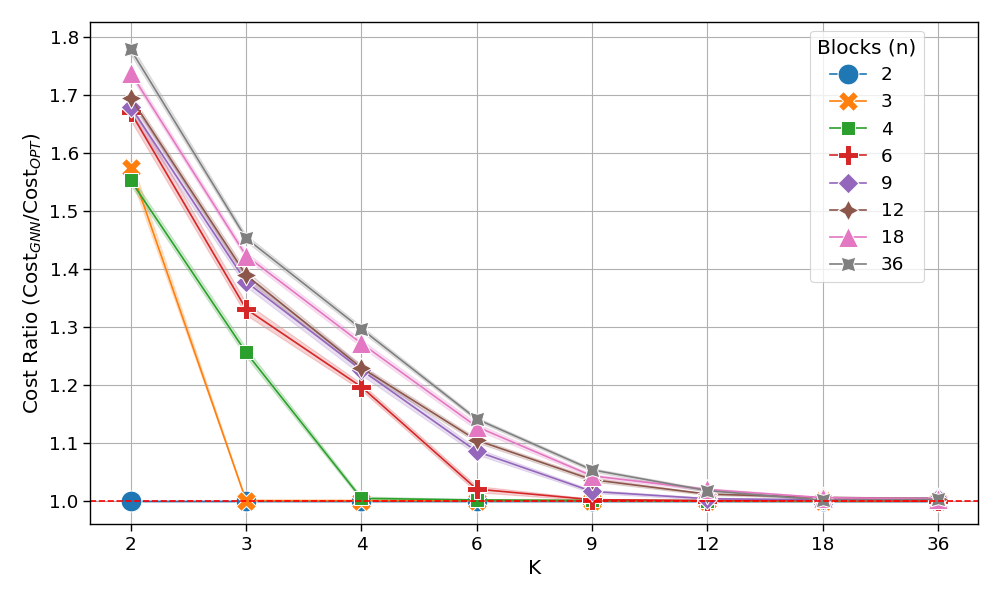

In [4]:
# plot at varying out_channels (GNN only, compare with its min)
df = pd.read_csv('../results/gnn_vs_gurobi_results_varying_out_channels.csv')
df_gurobi = pd.read_csv('../results/gnn_vs_gurobi_results_fixed_n.csv')
import seaborn as sns
import matplotlib.pyplot as plt

best_out = df_gurobi[['k', 'num_blocks', 'Gurobi']]
df_plot = df.merge(best_out, on=['k', 'num_blocks'], suffixes=('', '_best'))
df_plot['GNN'] = df_plot['GNN'] / df_plot['Gurobi']

fig = plt.figure(figsize=(10,6))

mapto_out_clusters = {v: i for i, v in enumerate(sorted(df_plot['out_clusters'].unique()))}
df_plot['out_clusters_mapped'] = df_plot['out_clusters'].map(mapto_out_clusters)

full_levels = sorted(df['num_blocks'].unique())
sns.lineplot(
    data=df_plot,
    x='out_clusters_mapped',
    y='GNN',
    hue='num_blocks',
    style='num_blocks',
    hue_order=full_levels,
    dashes=False,
    legend='full',
    markers=True,
    markersize=15,
    palette=sns.color_palette("tab10", n_colors=len(full_levels)),
    errorbar='se'
)

plt.legend(title='Blocks (n)', bbox_to_anchor=(0.8, 1), loc='upper left')
plt.axhline(1., color='red', linestyle='--')
plt.xticks(np.arange(len(df_plot['out_clusters'].unique())), sorted(df_plot['out_clusters'].unique()))
plt.xlabel('K')
#plt.xscale('log')
plt.ylabel(r'Cost Ratio ($\text{Cost}_{GNN} / \text{Cost}_{OPT}$)')


plt.grid()
plt.tight_layout()
plt.show()



#plt.savefig('./results/final/figures/gnn_vs_gurobi_varying_out_channels.pdf')


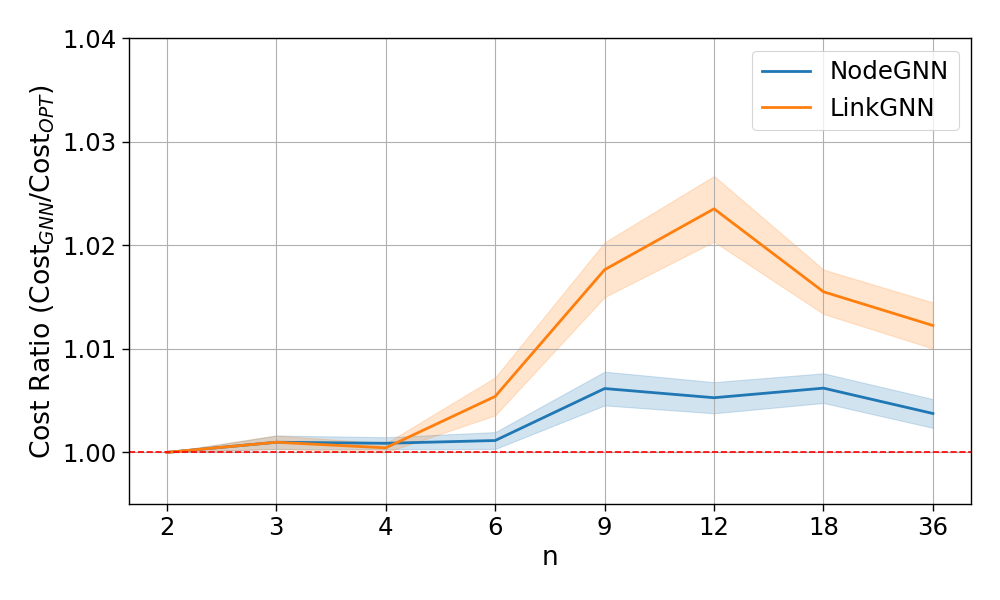

In [5]:
sns.set_context('paper', font_scale=2)

df = pd.read_csv('../results/gnn_vs_gurobi_results_fixed_n.csv')
# plot difference between gnn and gurobi
# and between linkgnn and gurobi
import matplotlib.pyplot as plt
import seaborn as sns
df['NodeGNN'] =( df['NodeGNN'])/df['Gurobi']
df['NodeGNN (rounded)'] = (df['GNN_converted'])/df['Gurobi']
#df['LinkGNN'] = (df['LinkGNN'])/df['Gurobi']
df['LinkGNN (rounded)'] = (df['LinkGNN_converted'])/df['Gurobi']
df['KwikCluster'] = (df['KwikCluster'])/df['Gurobi']
df['ModPivot'] = (df['ModPivot'])/df['Gurobi']

df_all = df.melt(id_vars=['num_blocks'], value_vars=['NodeGNN', 'NodeGNN (rounded)', 'LinkGNN', 'LinkGNN (rounded)'])
df_all['rounded'] = df_all['variable'].str.contains('rounded')
df_all['variable'] = df_all['variable'].str.replace(' (rounded)', '', regex=False)
df_all.loc[df_all.variable.isin(['KwikCluster', 'ModPivot']), 'rounded'] = True




# keep only rounded versions
df_all = df_all[df_all['rounded'] == True]

mapto_num_blocks = {v: i for i, v in enumerate(sorted(df_all['num_blocks'].unique()))}
df_all['num_blocks_mapped'] = df_all['num_blocks'].map(mapto_num_blocks)
fig = plt.figure(figsize=(10,6))
sns.lineplot(data=df_all, x='num_blocks_mapped', y='value',  hue='variable', markers=True, linewidth=2, markersize=15,errorbar='se')
plt.axhline(1., color='red', linestyle='--')
# on the x axis use only the num_blocks values present in the data
plt.xticks(np.arange(len(df['num_blocks'].unique())), sorted(df['num_blocks'].unique()))
plt.xlabel('n')
plt.ylabel(r'Cost Ratio ($\text{Cost}_{GNN} / \text{Cost}_{OPT}$)')
#plt.legend(title='Method Comparison')
# remove 'variable' and 'rounded' from legend
handles, labels = plt.gca().get_legend_handles_labels()
new_labels = []
new_handles = []
for label in labels:
    if ' (rounded)' in label:
        new_labels.append(label.replace(' (rounded)', ''))
    elif 'rounded' == label or label == 'variable':
        continue
    elif label == 'True':
        new_labels.append('Rounded')
    elif label == 'False':
        new_labels.append('Relaxed')
    else:
        new_labels.append(label)
    new_handles.append(handles[labels.index(label)])

plt.legend(new_handles, new_labels,  loc='best')
plt.ylim(0.995, 1.04)
plt.grid()
plt.tight_layout()
plt.show()
#fig.savefig('./results/final/all_vs_gurobi.pdf')